# Trajectory Inference with StaVIA: Official `toy_multifurcating` Test Data

If you use StaVIA in your research, please cite:

StaVIA: Spatio-Temporal Latent Embeddings and Vector field Inference for Collective Cell Migrations.

Paper: <https://www.biorxiv.org/content/10.1101/2024.07.04.601964v1
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        

Code: <https://github.com/ShobiStassen/VIA>

Documentation: <https://pyvia.readthedocs.io/en/latest/Atlas%20view%20examples.html>

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import omicverse as ov
from anndata import AnnData
from omicverse.external import VIA

import matplotlib.pyplot as plt
ov.plot_set()

/Users/mx/Study/repositories/omicverse-develop/.venv/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Load the official StaVIA test data

This notebook uses the `toy_multifurcating_M8_n1000d1000` test data released by the ShobiStassen/VIA repository. `group_id` is the simulated branch label and `true_time` is the simulated time, which can be used to check trajectory direction. For comparison, the older `t_via.ipynb` uses the VIA author-provided `scRNA_hematopoiesis` dataset loaded by `ov.single.scRNA_hematopoiesis()`.

In [2]:
base_url = "https://raw.githubusercontent.com/ShobiStassen/VIA/master/Datasets"
counts_url = f"{base_url}/toy_multifurcating_M8_n1000d1000.csv"
ids_url = f"{base_url}/toy_multifurcating_M8_n1000d1000_ids_with_truetime.csv"

counts = pd.read_csv(counts_url).rename(columns={"Unnamed: 0": "cell_id"}).set_index("cell_id")
cell_meta = pd.read_csv(ids_url)
cell_meta["cell_id_num"] = cell_meta["cell_id"].str[1:].astype(int)
cell_meta = cell_meta.sort_values("cell_id_num").reset_index(drop=True)
counts = counts.loc[cell_meta["cell_id"].astype(str)]

adata = AnnData(
    counts.to_numpy(dtype=float),
    obs=cell_meta[["group_id", "true_time"]].copy(),
)
adata.obs_names = cell_meta["cell_id"].astype(str).to_numpy()
adata.var_names = counts.columns.astype(str)
adata.obs["group_id"] = adata.obs["group_id"].astype("category")
adata.obs["true_time"] = pd.to_numeric(adata.obs["true_time"])
adata

AnnData object with n_obs × n_vars = 1000 × 1000
    obs: 'group_id', 'true_time'

In [3]:
adata.raw = adata.copy()
sc.pp.pca(adata, n_comps=50, random_state=4)
sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=15, n_pcs=30)
sc.tl.umap(adata, min_dist=1, random_state=4)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


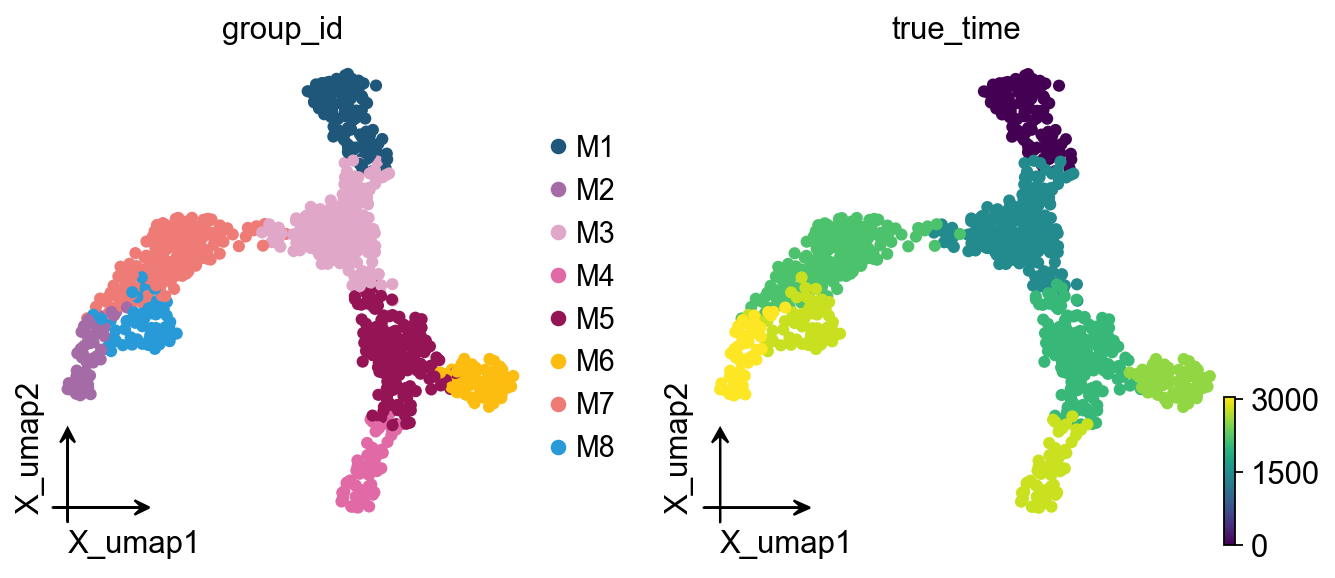

In [4]:
ov.pl.embedding(
    adata,
    basis="X_umap",
    color=["group_id", "true_time"],
    frameon="small",
    cmap="viridis",
)

In [5]:
# Official labels are stored in adata.obs["group_id"], and true_time can be used to check the simulated trajectory direction.
adata.obs[["group_id", "true_time"]].head()

   group_id  true_time
C1       M3       1444
C2       M6       2548
C3       M5       2048
C4       M7       2182
C5       M7       2182

## Construct and run the model

In [6]:
ncomps = 30
knn = 15
random_seed = 4
root = "M1"
memory = 0
use_rep = "X_pca"
clusters = "group_id"
basis = "X_umap"

stavia = ov.single.StaVIA(
    adata,
    use_rep=use_rep,
    n_comps=ncomps,
    basis=basis,
    cluster_key=clusters,
    spatial_key=None,  # Set to "spatial" for spatial AnnData
    time_key=None,
    sample_key=None,
    key_added="stavia",
    root=root,
    knn=knn,
    random_seed=random_seed,
    memory=memory,
    dataset="group",
    num_threads=1,
    n_iter_leiden=5,
    small_pop=5,
    num_mcmc_simulations=200,
    edgepruning_clustering_resolution=0.15,
    cluster_graph_pruning=0.15,
    resolution_parameter=1.5,
)

stavia.fit()
v0 = stavia.model
stavia_embedding = np.asarray(adata.obsm[stavia.basis])[:, [0, 1]]


2026-05-23 03:40:02.117233	Running VIA over input data of 1000 (samples) x 30 (features)
2026-05-23 03:40:02.117323	Knngraph has 15 neighbors
2026-05-23 03:40:02.284309	Finished global pruning of 15-knn graph used for clustering at level of 0.15. Kept 47.3 % of edges. 
2026-05-23 03:40:02.286104	Number of connected components used for clustergraph  is 1
2026-05-23 03:40:02.294707	Commencing community detection


2026-05-23 03:40:02.331189	Finished community detection. Found 34 clusters.
2026-05-23 03:40:02.331616	Merging 20 very small clusters (<5)
2026-05-23 03:40:02.331990	Finished detecting communities. Found 14 communities
2026-05-23 03:40:02.332041	Making cluster graph. Global cluster graph pruning level: 0.15
2026-05-23 03:40:02.333119	Graph has 1 connected components before pruning
2026-05-23 03:40:02.333733	Graph has 4 connected components after pruning
2026-05-23 03:40:02.334651	Graph has 1 connected components after reconnecting
2026-05-23 03:40:02.334819	0.0% links trimmed from local pruning relative to start
2026-05-23 03:40:02.334829	31.6% links trimmed from global pruning relative to start
initial links 38 and final_links_n 38
2026-05-23 03:40:02.335622	component number 0 out of  [0]
2026-05-23 03:40:02.340391	group root method
2026-05-23 03:40:02.340403	for component 0, the root is M1 and ri M1
cluster 0 has majority M7
cluster 1 has majority M3
cluster 2 has majority M5
cluster

2026-05-23 03:40:05.962378	Ended all multiprocesses, will retrieve and reshape
2026-05-23 03:40:05.975636	start computing walks with rw2 method


  0%|          | 0/1300 [00:00<?, ?it/s]

memory for rw2 hittings times  2. Using rw2 based pt
2026-05-23 03:40:09.111171	Identifying terminal clusters corresponding to unique lineages...
2026-05-23 03:40:09.111191	Closeness:[4, 5, 6, 7, 9, 11, 13]
2026-05-23 03:40:09.111198	Betweenness:[3, 5, 6, 7, 8, 9, 11, 13]
2026-05-23 03:40:09.111203	Out Degree:[0, 3, 5, 6, 7, 8, 11, 13]
2026-05-23 03:40:09.111313	Terminal clusters corresponding to unique lineages in this component are [5, 7, 8, 9, 11, 13] 
Via 1.0 lineage prob


...

2026-05-23 03:40:31.722120	From root 6,  the Terminal state 11 is reached 13 times.
terminal state 11 has probability [0.909 0.245 0.    0.245 0.909 0.    0.245 0.    0.    0.333 0.    1.
 0.446 0.333]


2026-05-23 03:40:36.261872	From root 6,  the Terminal state 13 is reached 20 times.
terminal state 13 has probability [0.87  0.2   0.    0.2   0.87  0.    0.2   0.    0.    0.952 0.    0.812
 0.4   1.   ]
2026-05-23 03:40:36.276931	There are (6) terminal clusters corresponding to unique lineages {5: 'M6', 7: 'M4', 8: 'M5', 9: 'M2', 11: 'M8', 13: 'M2'}
2026-05-23 03:40:36.276953	Begin projection of pseudotime and lineage likelihood
2026-05-23 03:40:36.361844	Cluster graph layout based on forward biasing
2026-05-23 03:40:36.362335	Starting make edgebundle viagraph...


2026-05-23 03:40:38.257028	Make via clustergraph edgebundle


2026-05-23 03:40:38.588996	Hammer dims: Nodes shape: (14, 2) Edges shape: (26, 3)
2026-05-23 03:40:38.589615	Graph has 1 connected components before pruning
2026-05-23 03:40:38.590210	Graph has 4 connected components after pruning
2026-05-23 03:40:38.590911	Graph has 1 connected components after reconnecting
2026-05-23 03:40:38.591047	11.5% links trimmed from local pruning relative to start
2026-05-23 03:40:38.591058	34.6% links trimmed from global pruning relative to start
initial links 26 and final_links_n 23
2026-05-23 03:40:38.591747	Start making edgebundle milestone with 150 milestones...This can be recomputed with make_edgebundle_milestone()
2026-05-23 03:40:38.591760	Start finding milestones


2026-05-23 03:40:38.828921	End milestones with 150
2026-05-23 03:40:38.829051	Will use via-pseudotime for edges, otherwise consider providing a list of numeric labels (single cell level) or via_object
2026-05-23 03:40:38.830849	Recompute weights
2026-05-23 03:40:38.839811	pruning milestone graph based on recomputed weights
2026-05-23 03:40:38.840535	Graph has 1 connected components before pruning
2026-05-23 03:40:38.841326	Graph has 1 connected components after pruning
2026-05-23 03:40:38.841434	Graph has 1 connected components after reconnecting
2026-05-23 03:40:38.842120	61.6% links trimmed from global pruning relative to start
2026-05-23 03:40:38.842156	regenerate igraph on pruned edges
2026-05-23 03:40:38.845954	Setting numeric label as single cell pseudotime for coloring edges
2026-05-23 03:40:38.849593	Making smooth edges
REMEMBER TO RE-INCLUDE the PLT.SHOW HERE - COMMENTING IT OUT FOR NOW
2026-05-23 03:40:38.988002	Time elapsed 36.8 seconds


## StaVIA graph structure and pseudotime

tune edges False


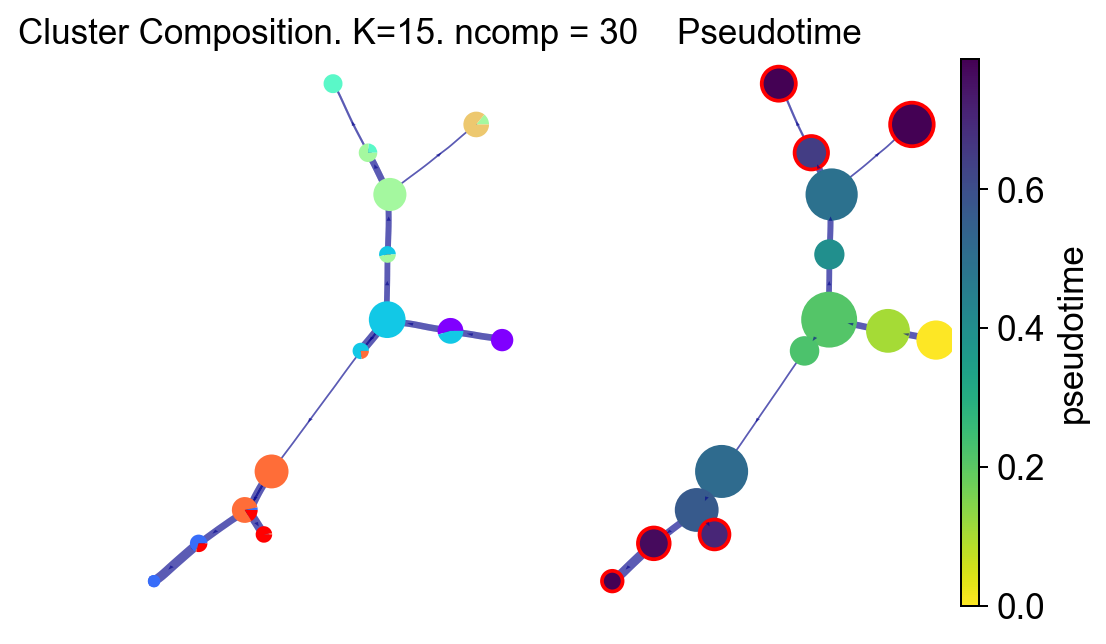

In [7]:
fig, ax, ax1 = VIA.core.plot_piechart_viagraph(
    via_object=v0,
    dpi=90,
    ax_text=False,
    show_legend=False,
)
fig.set_size_inches(6, 4)
plt.show()


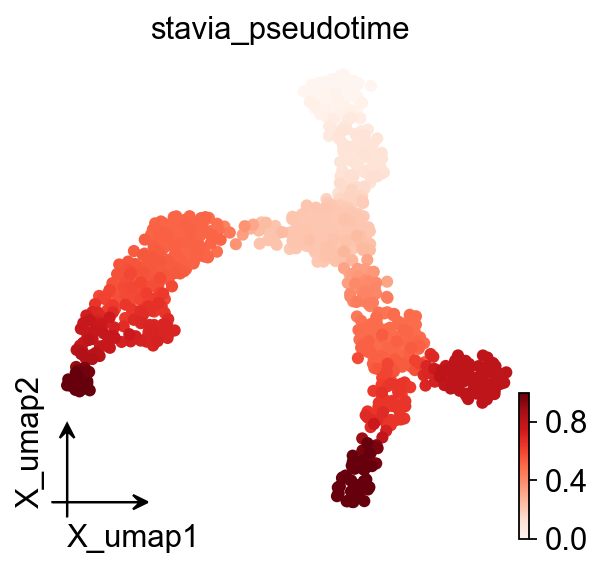

In [8]:
ov.pl.embedding(
    adata,
    basis=basis,
    color=[stavia.pseudotime_key],
    frameon="small",
    cmap="Reds",
)

## StaVIA trajectory projection

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00

 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

...

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00

 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00

2026-05-23 03:40:41.764159	Super cluster 5 is a super terminal with sub_terminal cluster 5
2026-05-23 03:40:41.764478	Super cluster 7 is a super terminal with sub_terminal cluster 7
2026-05-23 03:40:41.764503	Super cluster 8 is a super terminal with sub_terminal cluster 8
2026-05-23 03:40:41.764522	Super cluster 9 is a super terminal with sub_terminal cluster 9
2026-05-23 03:40:41.764539	Super cluster 11 is a super terminal with sub_terminal cluster 11
2026-05-23 03:40:41.764555	Super cluster 13 is a super terminal with sub_terminal cluster 13


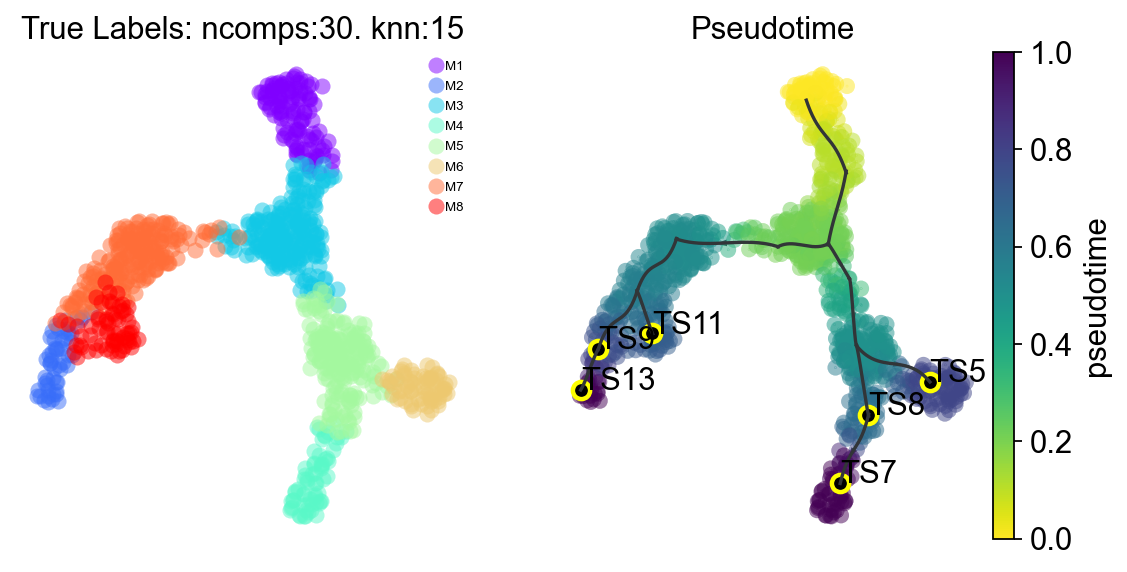

In [9]:
fig, ax, ax1 = VIA.core.plot_trajectory_curves(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=80,
    draw_all_curves=False,
)
fig.set_size_inches(8, 4)
plt.show()


## StaVIA lineage probabilities

Following the probabilistic pathways section in `t_via.ipynb`, we first show all terminal lineage probabilities and then inspect the first two terminal lineages separately.

2026-05-23 03:40:42.007530	Marker_lineages: [5, 7, 8, 9, 11, 13]
2026-05-23 03:40:42.008410	The number of components in the original full graph is 1
2026-05-23 03:40:42.008434	For downstream visualization purposes we are also constructing a low knn-graph 


2026-05-23 03:40:42.260670	Check sc pb 1.0000000000000002 
f getting majority comp
2026-05-23 03:40:42.268882	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 5: [6, 3, 1, 10, 2, 5]
2026-05-23 03:40:42.268900	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 7: [6, 3, 1, 10, 2, 8, 7]
2026-05-23 03:40:42.268907	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 8: [6, 3, 1, 10, 2, 8]
2026-05-23 03:40:42.268914	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 9: [6, 3, 1, 12, 0, 4, 9]
2026-05-23 03:40:42.268920	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 11: [6, 3, 1, 12, 0, 4, 11]
2026-05-23 03:40:42.268925	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 13: [6, 3, 1, 12, 0, 4, 9, 13]
setting vmin to 0.0
2026-05-23 03:40:42.287760	Revised Cluster level path on sc-knnGraph from Root Cluster 6 to Terminal Cluster 5

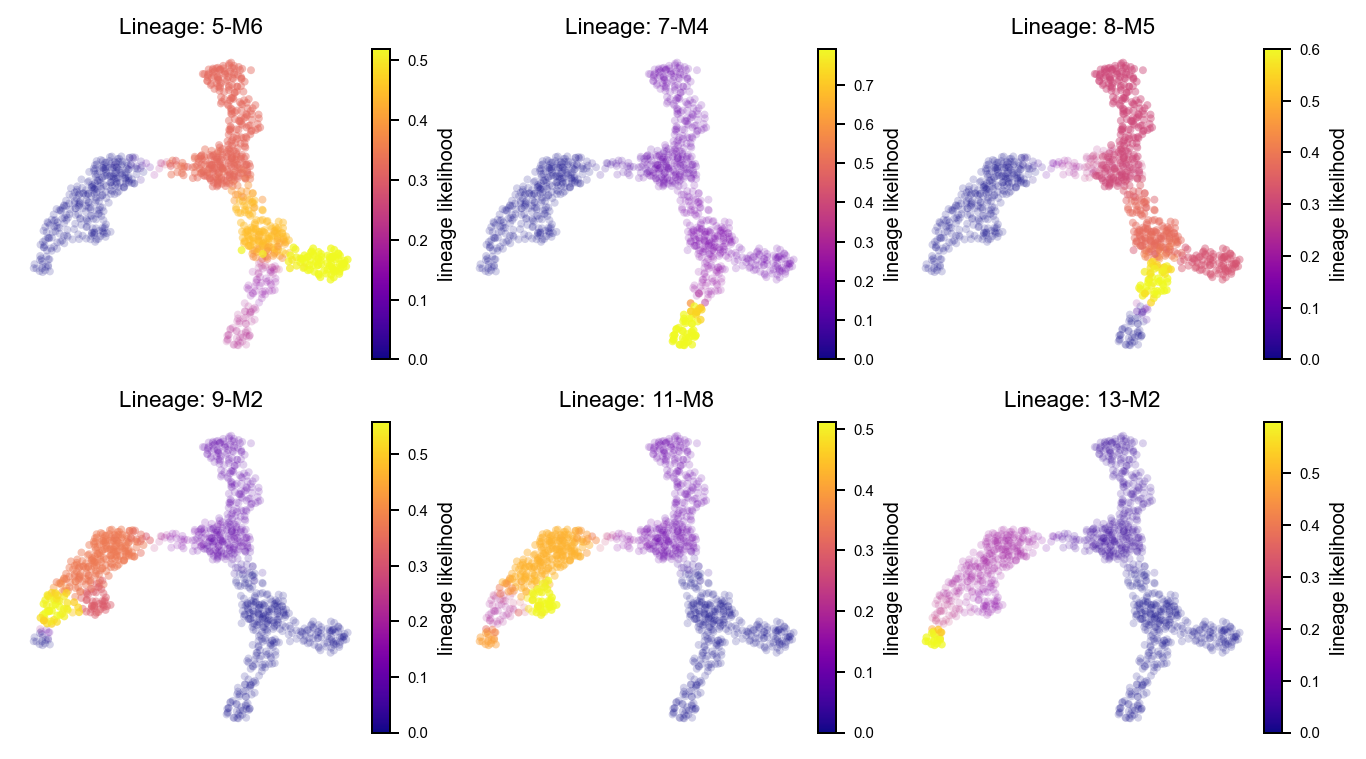

In [10]:
fig, axs = VIA.core.plot_sc_lineage_probability(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=90,
)
fig.set_size_inches(9, 5)
plt.show()


2026-05-23 03:40:42.468244	Marker_lineages: [5, 7]
2026-05-23 03:40:42.468541	The number of components in the original full graph is 1
2026-05-23 03:40:42.468554	For downstream visualization purposes we are also constructing a low knn-graph 


2026-05-23 03:40:42.719363	Check sc pb 1.0000000000000002 
f getting majority comp
2026-05-23 03:40:42.727626	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 5: [6, 3, 1, 10, 2, 5]
2026-05-23 03:40:42.727645	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 7: [6, 3, 1, 10, 2, 8, 7]
setting vmin to 0.0
2026-05-23 03:40:42.739627	Revised Cluster level path on sc-knnGraph from Root Cluster 6 to Terminal Cluster 5 along path: [6, 6, 6, 3, 1, 10, 2, 5, 5, 5, 5]
setting vmin to 0.0
2026-05-23 03:40:42.746117	Revised Cluster level path on sc-knnGraph from Root Cluster 6 to Terminal Cluster 7 along path: [6, 6, 6, 3, 1, 10, 2, 8, 7, 7, 7, 7, 7]


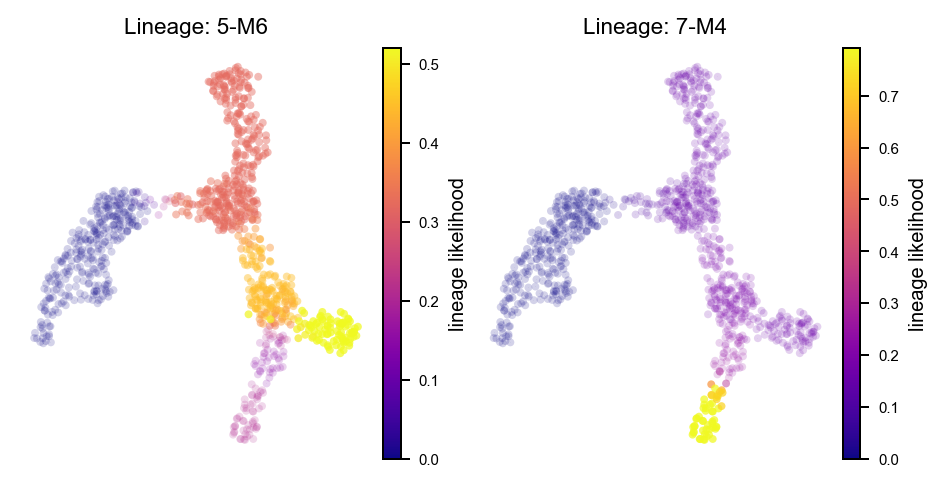

In [11]:
marker_lineages = list(v0.terminal_clusters)[:2]

fig, axs = VIA.core.plot_sc_lineage_probability(
    via_object=v0,
    embedding=stavia_embedding,
    marker_lineages=marker_lineages,
    dpi=90,
)
fig.set_size_inches(6, 3)
plt.show()


## StaVIA lineage path atlas view

location of 5 is at [0] and 0
setting vmin to 0.0


location of 7 is at [1] and 1
setting vmin to 0.0


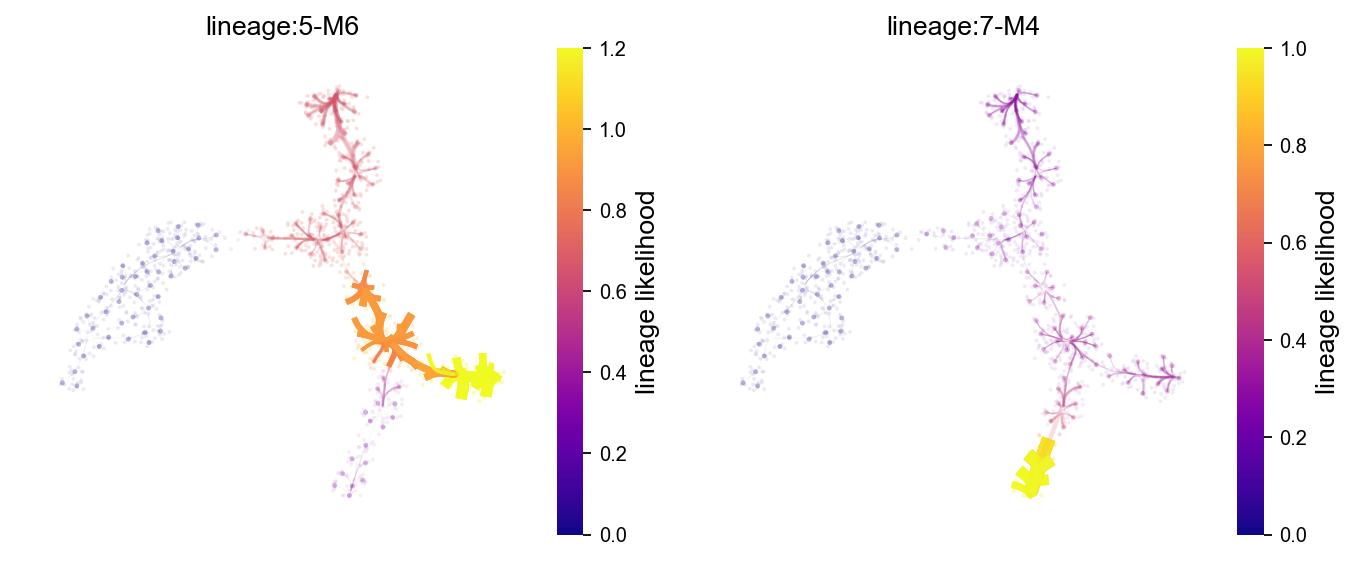

In [12]:
lineage_pathway = list(v0.terminal_clusters)[:2]

fig, axs = VIA.core.plot_atlas_view(
    via_object=v0,
    dpi=80,
    lineage_pathway=lineage_pathway,
    fontsize_title=12,
    fontsize_labels=12,
)
fig.set_size_inches(10, 4)
plt.show()

## StaVIA stream plots

Following the stream plot examples in `t_via.ipynb`, we show stream plots colored by annotation and by pseudotime.

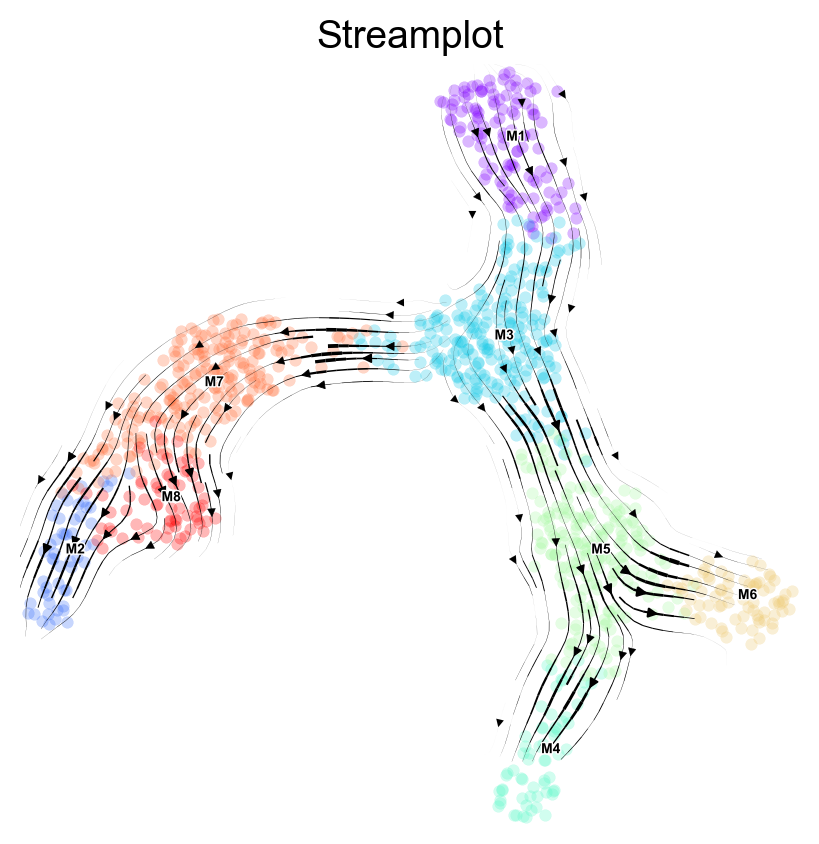

In [13]:
fig, ax = VIA.core.via_streamplot(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=100,
    density_grid=1.0,
    density_stream=2.5,
    scatter_size=18,
    scatter_alpha=0.28,
    linewidth=0.8,
)
fig.set_size_inches(5, 5)
plt.show()


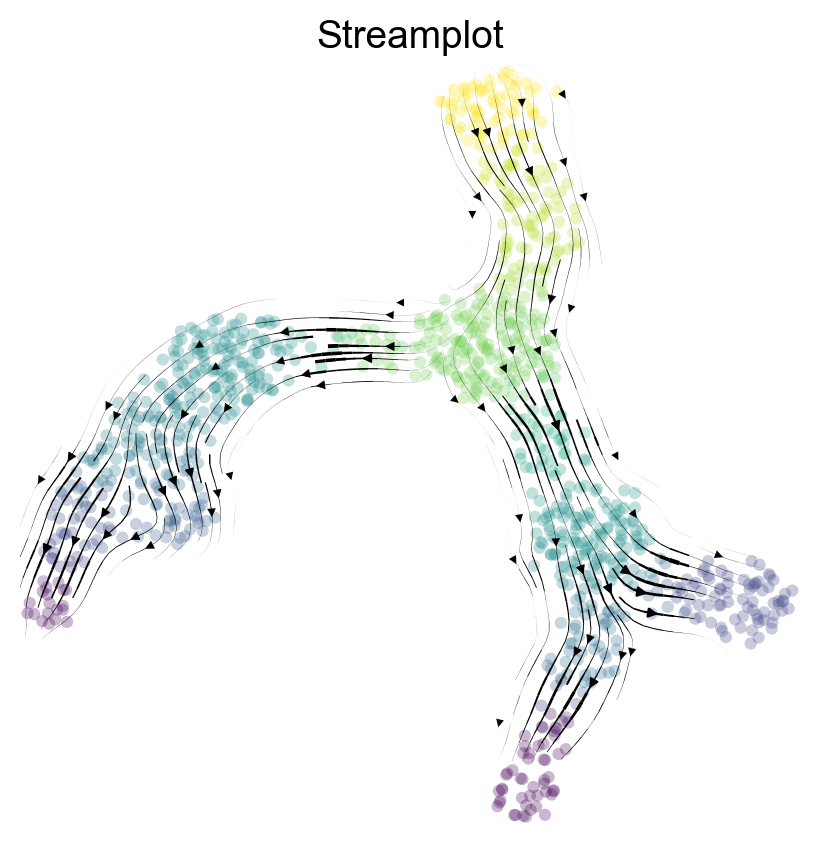

In [14]:
fig, ax = VIA.core.via_streamplot(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=100,
    density_grid=1.0,
    density_stream=2.5,
    scatter_size=18,
    scatter_alpha=0.28,
    linewidth=0.8,
    color_scheme="time",
    min_mass=1,
    cutoff_perc=5,
    marker_edgewidth=0.1,
    smooth_transition=1,
    smooth_grid=0.5,
)
fig.set_size_inches(5, 5)
plt.show()


## Gene / feature graph visualization

Following the gene/feature graph section in `t_via.ipynb`, selected features are first smoothed with the fitted VIA graph in a MAGIC-like manner and then shown at the cluster level.

In [15]:
stavia_marker_genes = [
    gene
    for gene in ["G1", "G2", "G3", "G4", "G5", "G6"]
    if gene in adata.raw.var_names
]

df_gene = adata.raw[:, stavia_marker_genes].to_adata().to_df()
df_magic = v0.do_impute(
    df_gene,
    magic_steps=3,
    gene_list=stavia_marker_genes,
)

shape of transition matrix raised to power 3 (1000, 1000)


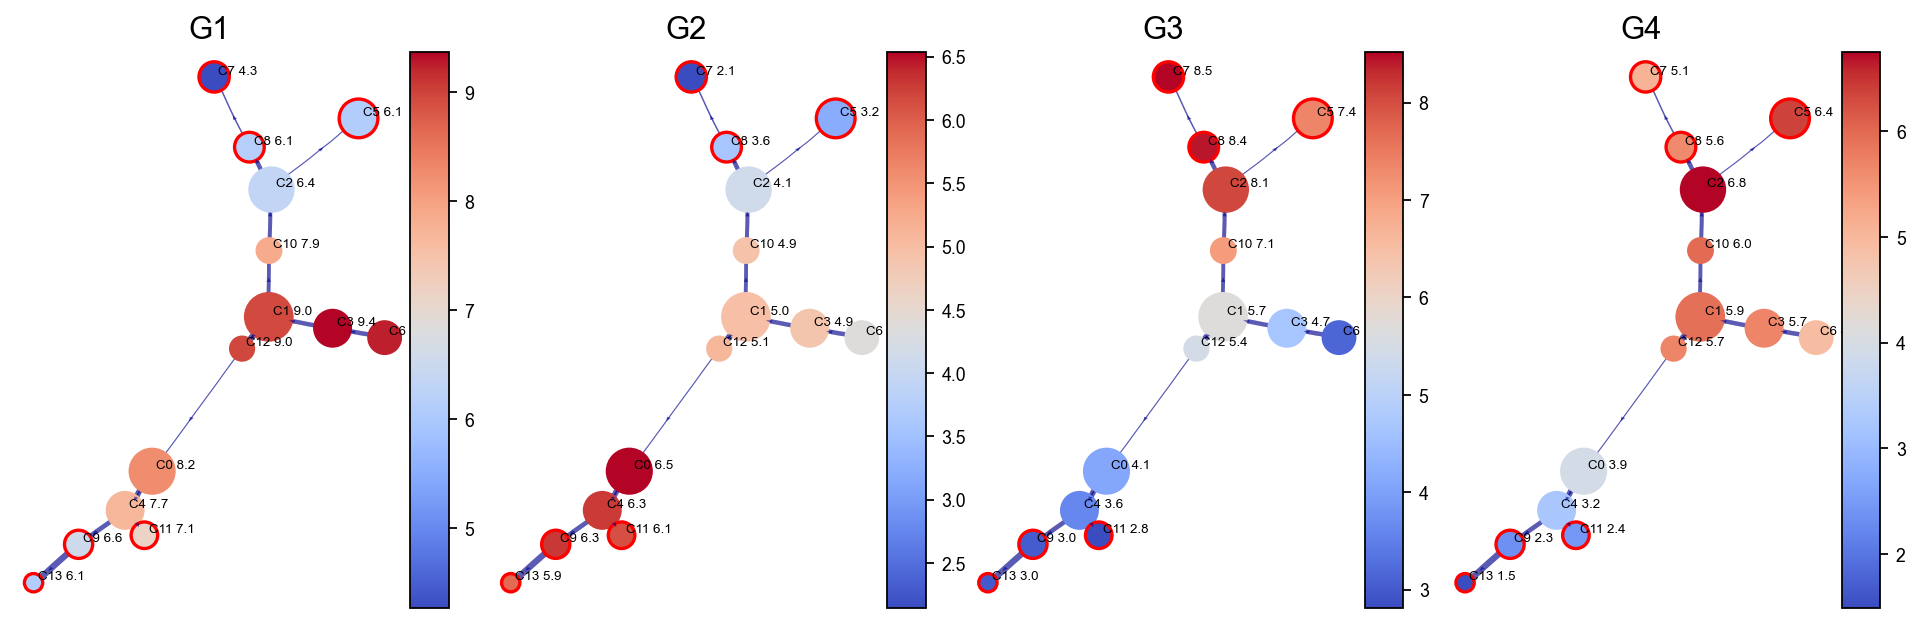

In [16]:
fig, axs = VIA.core.plot_viagraph(
    via_object=v0,
    type_data="gene",
    df_genes=df_magic.copy(),
    gene_list=stavia_marker_genes[:4],
    arrow_head=0.1,
)
fig.set_size_inches(12, 4)
plt.show()

## StaVIA lineage gene dynamics

VIA estimates gene dynamics along detected terminal lineages. We first show native VIA trend curves and heatmaps, then compare them with the general OmicVerse dynamic trend and dynamic heatmap workflow.

Area under curve G1 for branch M6 is 5.9976576637811245
Area under curve G1 for branch M4 is 7.037647276171276
Area under curve G1 for branch M5 is 5.9729927151835795
Area under curve G1 for branch M2 is 6.891188373159115
Area under curve G1 for branch M8 is 6.153775365850442
Area under curve G1 for branch M2 is 7.924280442495617
Area under curve G2 for branch M6 is 3.4438356577647733
Area under curve G2 for branch M4 is 3.9730264220746445
Area under curve G2 for branch M5 is 3.4281218940011677
Area under curve G2 for branch M2 is 4.818711483846181
Area under curve G2 for branch M8 is 4.094146866442365
Area under curve G2 for branch M2 is 5.8180379502109965
Area under curve G3 for branch M6 is 5.235727543043163
Area under curve G3 for branch M4 is 6.994198196529512
Area under curve G3 for branch M5 is 5.328764513419543
Area under curve G3 for branch M2 is 3.50401839592964
Area under curve G3 for branch M8 is 3.18722235112096
Area under curve G3 for branch M2 is 3.9333306954286473
Area 

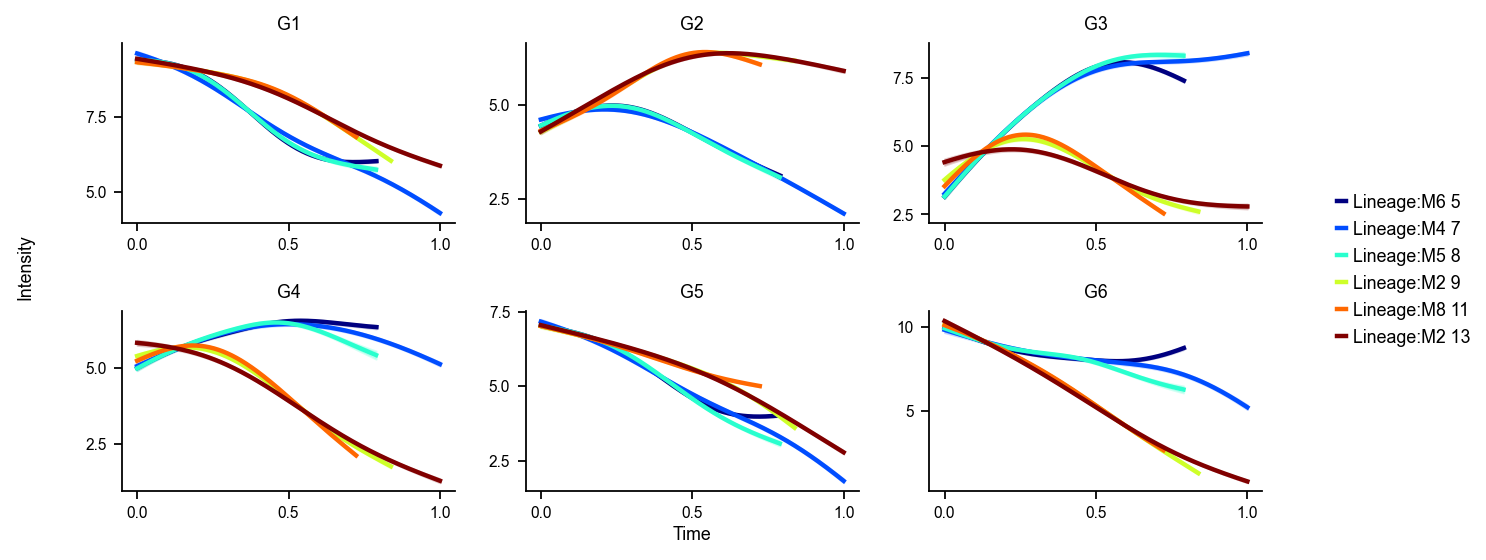

In [17]:
fig, axs = VIA.core.get_gene_expression(
    via_object=v0,
    gene_exp=df_magic[stavia_marker_genes],
    marker_genes=stavia_marker_genes,
    dpi=80,
    figsize=(10, 4),
    ncols=3,
    legend_loc="right",
)
plt.show()

branches [5, 7]


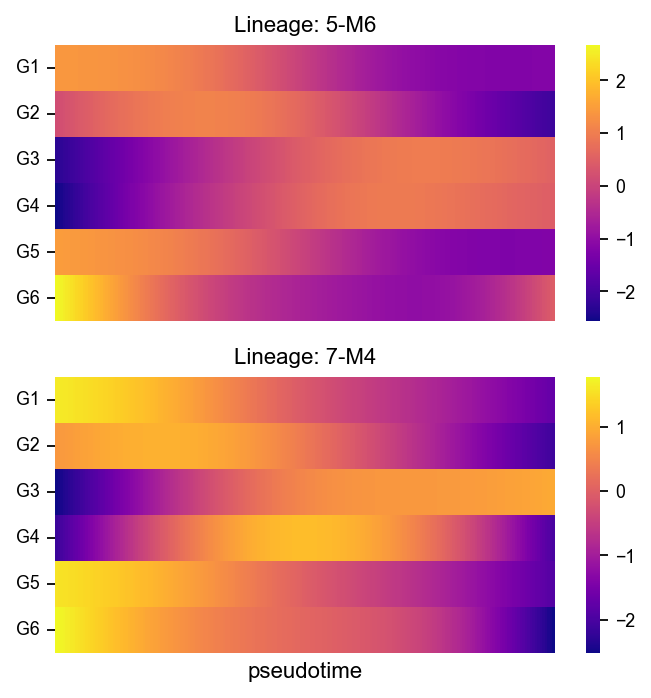

In [18]:
marker_lineages = list(v0.terminal_clusters)[:2]

fig, axs = VIA.core.plot_gene_trend_heatmaps(
    via_object=v0,
    df_gene_exp=df_magic[stavia_marker_genes],
    cmap="plasma",
    marker_lineages=marker_lineages,
)
fig.set_size_inches(5, max(3, 2.5 * len(marker_lineages)))
plt.show()